<a href="https://colab.research.google.com/github/vkgarapa/BLcase-study/blob/master/BLCaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Description / Business understanding

### Business Sponsors

The following case study is sponsored by bottom line technologies

### Objective

The study is conducted to predict if the client will subscribe a term deposit or not. The dataset consists of 41188 instances where we have 20+ attributes. 

### Goal

NOTE: the following is an additon to data to better understand the behaviour of the model and its subsequent impact on the business understanding

The goal is to do a cost benefit analysis to understand the operational costs and profits genrated by clients term depsots.

### Data Description

Input variables: 
 
Client data:    
1 - age (numeric)    
2 - job : type of job (categorical: "admin.","bluecollar","entrepreneur","housemaid","management","retired","selfemployed","services","student","technician","unemployed","unknown")    
3 - marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)    
4 - education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university. degree","unknown")    
5 - default: has credit in default? (categorical: "no","yes","unknown") 6 - housing: has housing loan? (categorical: "no","yes","unknown")    
7 - loan: has personal loan? (categorical: "no","yes","unknown")    # related with the last contact of the current campaign:    
8 - contact: contact communication type (categorical: "cellular","telephone")     
9 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")   
10 - day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri")   
11 - duration: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. 
 
Additional attributes:   
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)   
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)   
14 - previous: number of contacts performed before this campaign and for this client (numeric)   
15 - poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")  

social and economic context attributes   
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)   
17 - cons.price.idx: consumer price index - monthly indicator (numeric) 18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)      

19 - euribor3m: euribor 3 month rate - daily indicator (numeric)   
20 - nr.employed: number of employees - quarterly indicator (numeric) 
 
Output variable (desired target): 
 
21 - y - has the client subscribed a term deposit? (binary: "yes","no") 
 
Missing Attribute Values: There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques. 
 

# Analytical Approach

we will express the following problem in the context of statistical and machine learning techniques by classification using ensemble methods like gradient boosting

# Importing Packages

In [1]:
# Importing packages
import pandas as pd
import numpy as np
import time
from collections import Counter

# Importing plotting packages
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
import plotly.offline as py
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
import plotly.express as px
import plotly.graph_objects as go


# Sampling Packages
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from mlxtend.plotting import plot_learning_curves
from yellowbrick.model_selection import LearningCurve
from yellowbrick.features.importances import FeatureImportances

!pip install bayesian-optimization
from bayes_opt import BayesianOptimization
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split,StratifiedKFold, learning_curve, validation_curve
from sklearn.metrics import auc,confusion_matrix
import xgboost as xgb
from sklearn.metrics import roc_auc_score,roc_curve, precision_score, recall_score, f1_score, accuracy_score

# Call once to configure Bokeh to display plots inline in the notebook.
output_notebook()

/usr/local/lib/python3.6/dist-packages/sklearn/externals/six.py:31: FutureWarning:

The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning:

The sklearn.neighbors.base module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.neighbors. Anything that cannot be imported from sklearn.neighbors is now part of the private API.

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning:

The sklearn.metrics.classification module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.metrics. Anything that cannot be imported from sklearn.metrics is now pa

  Created wheel for bayesian-optimization: filename=bayesian_optimization-1.0.1-cp36-none-any.whl size=10032 sha256=ebdb118290aa23852461c4b1d9d61abd5e6214e75654241e6d8d2d6d13ecab00
  Stored in directory: /root/.cache/pip/wheels/1d/0d/3b/6b9d4477a34b3905f246ff4e7acf6aafd4cc9b77d473629b77
Successfully built bayesian-optimization


# Data Compilation

## Data requirements

for the following case study, the data has been provided. thereby, it does not require a data requirment category.

## Data collection

In [2]:
data = pd.read_csv('/content/dataset.csv', sep=";",header=None)
data = np.array([x.replace(';', ',').replace('"', '').strip().split(',') for x in data[0]])
data = pd.DataFrame(data=data[0:,1:],    # values
                    index=data[0:,0],    # 1st column as index
                    columns=data[0,1:])  # 1st row as the column names

data.reset_index(level=0, inplace=True)
data.rename(columns={'index':'age'}, inplace = True)
data = data.drop([0], axis=0)
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
5,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


Lets take a look at the types of features in the data

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41188 entries, 1 to 41188
Data columns (total 21 columns):
age               41188 non-null object
job               41188 non-null object
marital           41188 non-null object
education         41188 non-null object
default           41188 non-null object
housing           41188 non-null object
loan              41188 non-null object
contact           41188 non-null object
month             41188 non-null object
day_of_week       41188 non-null object
duration          41188 non-null object
campaign          41188 non-null object
pdays             41188 non-null object
previous          41188 non-null object
poutcome          41188 non-null object
emp.var.rate      41188 non-null object
cons.price.idx    41188 non-null object
cons.conf.idx     41188 non-null object
euribor3m         41188 non-null object
nr.employed       41188 non-null object
y                 41188 non-null object
dtypes: object(21)
memory usage: 6.9+ MB


In [4]:
data.describe()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,78,12,4,8,3,3,3,2,10,5,1544,42,27,8,3,10,26,26,316,11,2
top,31,admin.,married,university.degree,no,yes,no,cellular,may,thu,90,1,999,0,nonexistent,1.4,93.994,-36.4,4.857,5228.1,no
freq,1947,10422,24928,12168,32588,21576,33950,26144,13769,8623,170,17642,39673,35563,35563,16234,7763,7763,2868,16234,36548


## Data Understanding

It can be observed that we have to change some of the feature data types

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41188 entries, 1 to 41188
Data columns (total 21 columns):
age               41188 non-null object
job               41188 non-null object
marital           41188 non-null object
education         41188 non-null object
default           41188 non-null object
housing           41188 non-null object
loan              41188 non-null object
contact           41188 non-null object
month             41188 non-null object
day_of_week       41188 non-null object
duration          41188 non-null object
campaign          41188 non-null object
pdays             41188 non-null object
previous          41188 non-null object
poutcome          41188 non-null object
emp.var.rate      41188 non-null object
cons.price.idx    41188 non-null object
cons.conf.idx     41188 non-null object
euribor3m         41188 non-null object
nr.employed       41188 non-null object
y                 41188 non-null object
dtypes: object(21)
memory usage: 6.9+ MB


In [0]:
# We need to take a closer look of the data and its behaviour
#data.duration.value_counts()
#data['nr.employed'].value_counts()

In [7]:
data[['duration','campaign','pdays','previous','age']] = data[['duration','campaign','pdays','previous','age']].astype('int')
data[['emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed']] = data[['emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed']].astype('float64')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41188 entries, 1 to 41188
Data columns (total 21 columns):
age               41188 non-null int64
job               41188 non-null object
marital           41188 non-null object
education         41188 non-null object
default           41188 non-null object
housing           41188 non-null object
loan              41188 non-null object
contact           41188 non-null object
month             41188 non-null object
day_of_week       41188 non-null object
duration          41188 non-null int64
campaign          41188 non-null int64
pdays             41188 non-null int64
previous          41188 non-null int64
poutcome          41188 non-null object
emp.var.rate      41188 non-null float64
cons.price.idx    41188 non-null float64
cons.conf.idx     41188 non-null float64
euribor3m         41188 non-null float64
nr.employed       41188 non-null float64
y                 41188 non-null object
dtypes: float64(5), int64(5), object(11)
memory usa

#### Initial insights about data

In [0]:
#data['campaign'].value_counts()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41188 entries, 1 to 41188
Data columns (total 21 columns):
age               41188 non-null int64
job               41188 non-null object
marital           41188 non-null object
education         41188 non-null object
default           41188 non-null object
housing           41188 non-null object
loan              41188 non-null object
contact           41188 non-null object
month             41188 non-null object
day_of_week       41188 non-null object
duration          41188 non-null int64
campaign          41188 non-null int64
pdays             41188 non-null int64
previous          41188 non-null int64
poutcome          41188 non-null object
emp.var.rate      41188 non-null float64
cons.price.idx    41188 non-null float64
cons.conf.idx     41188 non-null float64
euribor3m         41188 non-null float64
nr.employed       41188 non-null float64
y                 41188 non-null object
dtypes: float64(5), int64(5), object(11)
memory usa

In [10]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
data.job.value_counts()

admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: job, dtype: int64

In [12]:
data.groupby(['job','y']).mean()

age    duration  ...  euribor3m  nr.employed
job           y                           ...                        
admin.        no   38.219846  215.093385  ...   3.786567  5175.512051
              yes  37.968935  517.414201  ...   1.965078  5087.736760
blue-collar   no   39.582057  229.878018  ...   3.835402  5178.296031
              yes  39.200627  732.673981  ...   2.915715  5139.410658
entrepreneur  no   41.703453  225.632883  ...   3.881632  5180.205631
              yes  41.935484  667.540323  ...   2.818839  5134.504839
housemaid     no   44.705451  218.778826  ...   4.243082  5190.553249
              yes  52.650943  535.537736  ...   1.908717  5080.316981
management    no   42.309707  220.828197  ...   3.785477  5175.037442
              yes  42.783537  543.804878  ...   2.232896  5100.271037
retired       no   59.926128  224.263608  ...   3.249794  5146.043313
              yes  68.253456  420.235023  ...   1.348569  5051.795392
self-employed no   40.176887  222.220912  ...   3.854206  5177.958019
              yes  38.006711  622.020134  ...   2.282242  5108.494631
services      no   38.090236  225.047998  ...   3.793805  5176.038069
              yes  36.077399  634.851393  ...   2.631139  5121.504954
student       no   26.396667  228.851667  ...   2.208683  5104.507500
              yes  24.800000  403.316364  ...   1.176313  5045.426182
technician    no   38.600033  213.452021  ...   4.012318  5184.951705
              yes  37.746575  553.190411  ...   2.239584  5099.017123
unemployed    no   39.844828  212.706897  ...   3.775461  5172.245172
              yes  39.062500  471.451389  ...   1.600444  5065.995833
unknown       no   45.375427  204.559727  ...   4.154038  5182.742662
              yes  47.054054  517.756757  ...   2.325622  5095.240541

[24 rows x 10 columns]

In [13]:
data[data['y']=='yes'].groupby(['marital','default','housing','loan']).count()

age  job  ...  nr.employed    y
marital  default housing loan               ...                  
divorced no      no      no       172  172  ...          172  172
                         yes       25   25  ...           25   25
                 unknown unknown    7    7  ...            7    7
                 yes     no       188  188  ...          188  188
                         yes       39   39  ...           39   39
         unknown no      no        18   18  ...           18   18
                         yes        3    3  ...            3    3
                 unknown unknown    1    1  ...            1    1
                 yes     no        18   18  ...           18   18
                         yes        5    5  ...            5    5
married  no      no      no       838  838  ...          838  838
                         yes      129  129  ...          129  129
                 unknown unknown   50   50  ...           50   50
                 yes     no       992  992  ...          992  992
                         yes      210  210  ...          210  210
         unknown no      no       131  131  ...          131  131
                         yes       14   14  ...           14   14
                 unknown unknown   10   10  ...           10   10
                 yes     no       137  137  ...          137  137
                         yes       21   21  ...           21   21
single   no      no      no       552  552  ...          552  552
                         yes       96   96  ...           96   96
                 unknown unknown   39   39  ...           39   39
                 yes     no       725  725  ...          725  725
                         yes      123  123  ...          123  123
         unknown no      no        34   34  ...           34   34
                         yes        7    7  ...            7    7
                 yes     no        34   34  ...           34   34
                         yes       10   10  ...           10   10
unknown  no      no      no         7    7  ...            7    7
                 yes     no         4    4  ...            4    4
                         yes        1    1  ...            1    1

[32 rows x 17 columns]

In [14]:
print(d[d['y']=='yes'].groupby(['job','default','housing','loan']).count().to_string())

NameError: ignored

In [0]:
data.groupby(['education','y']).mean()

#### Visualization of data

Currently, five generations make up our society. Each of those five generations has an active role in the marketplace. Depending on the specific workplace, the workforce includes four to five generations. Here are the birth years for each generation:

Gen Z, iGen, or Centennials: Born 1996 – TBD

Millennials or Gen Y: Born 1977 – 1995

Generation X: Born 1965 – 1976

Baby Boomers: Born 1946 – 1964

Traditionalists or Silent Generation: Born 1945 and before



In [0]:
d = data.copy()
d['genr'] = d['age']

In [0]:
def genr(df):
  r = []

  for i in d.age:
    if i >= 55 and i < 74:
      i = "Baby Boomers (74 - 55)"
    elif i >= 43 and i < 55:
      i = "Gen X (55 - 43)"
    elif i >= 24 and i < 43:
      i = "Gen Y (43 - 24)" 
    elif i < 24:
      i = "Gen Z ( < 24)"
    elif i >= 74:
      i = "Traditionalists (>74)"

    r.append(i)

  df.genr = r
  return df.genr

In [0]:
genr(d)
d.genr.value_counts()

In [0]:
import gc
gc.collect()

In [0]:
sns.countplot(x='genr',data=d, hue='y')

In [0]:
plt.figure(figsize=[12,7])
sns.countplot(x=d['genr'][d['y']=='yes'],data=d, hue='job')

In [0]:
plt.figure(figsize=[12,7])
sns.countplot(x=d['genr'][d['y']=='no'],data=d, hue='job')

In [0]:
sns.lineplot(x="month", y="cons.price.idx", hue='genr',data=d)

In [0]:
plt.figure(figsize=[12,9])
sns.lineplot(x="job", y="cons.conf.idx", hue='month',data=d)

In [0]:
sns.lineplot(x="month", y="cons.conf.idx", hue='y',data=d)

In [0]:
sns.lineplot(x="genr", y="cons.price.idx", hue='y',data=d)

In [0]:
sns.lineplot(x="genr", y="cons.conf.idx", hue='y',data=d)

In [0]:
plt.figure(figsize=[12,9])
sns.lineplot(x="job", y="cons.price.idx", hue='y',data=d)

In [0]:
plt.figure(figsize=[12,9])
sns.lineplot(x="job", y="previous", hue='y',data=d)

In [0]:
plt.figure(figsize=[12,9])
sns.lineplot(x="education", y="cons.conf.idx", hue='genr',data=d)

In [0]:
plt.figure(figsize=[12,9])
sns.lineplot(x="job", y="euribor3m", hue='y',data=d)

In [0]:
plt.figure(figsize=[12,9])
sns.lineplot(x="genr", y="euribor3m", hue='y',data=d)

In [0]:
plt.figure(figsize=[12,7])
sns.countplot(x=d['genr'][d['y']=='no'],data=d, hue='default')

In [15]:
plt.figure(figsize=[12,7])
sns.countplot(x=d['job'][d['y']=='yes'],data=d, hue='loan')

NameError: ignored

<Figure size 864x504 with 0 Axes>

In [0]:
plt.figure(figsize=[12,7])
sns.countplot(x=d['genr'][d['y']=='no'],data=d, hue='marital')

In [0]:
plt.figure(figsize=[12,7])
sns.countplot(x=d['genr'],data=d, hue='housing')

In [0]:
plt.figure(figsize=[12,9])
sns.countplot(x='education',data=data, hue='y')

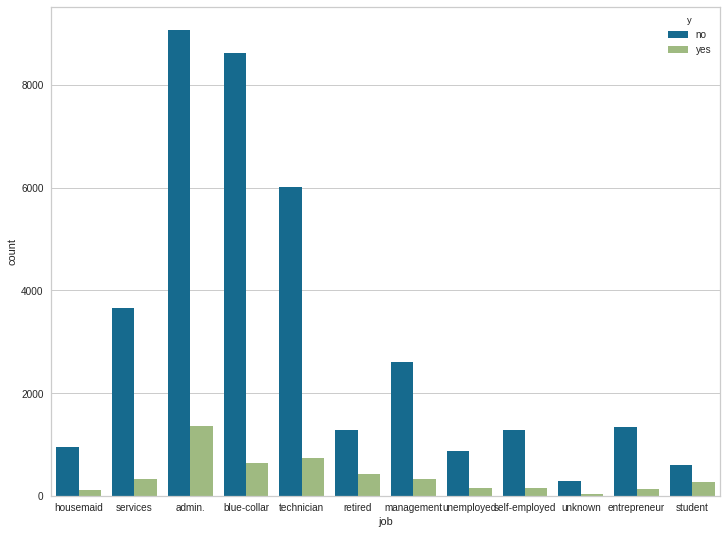

In [16]:
plt.figure(figsize=[12,9])
sns.countplot(x='job',data=data, hue='y')

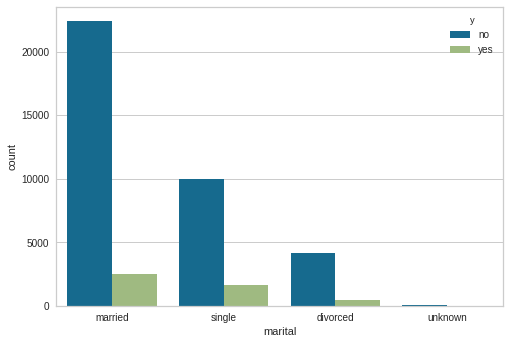

In [17]:
sns.countplot(x='marital',data=data, hue='y')

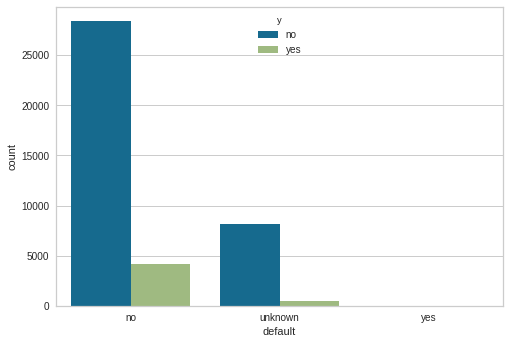

In [18]:
sns.countplot(x='default',data=data, hue='y')

In [19]:
fig = px.box(data, x="job", y="age", color="default",
             notched=True, # used notched shape
             title="Box plot of Job (marital) vs age",
             hover_data=["y"] 
            )
fig.show()



In [20]:
fig = px.box(data, x="job", y="age", color="loan",
             notched=True, # used notched shape
             title="Box plot of Job (marital) vs age",
             hover_data=["y"] 
            )
fig.show()

# Data Preparation

## Data cleaning

In [21]:
data.duration.value_counts()

85      170
90      170
136     168
73      167
124     164
       ... 
1108      1
980       1
4918      1
2453      1
2015      1
Name: duration, Length: 1544, dtype: int64

In [22]:
data['y'].value_counts()

no     36548
yes     4640
Name: y, dtype: int64

In [23]:
data.job.value_counts()

admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: job, dtype: int64

In [24]:
data.month.value_counts()

may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: month, dtype: int64

In [25]:
data['pdays'][data['pdays']==999] = 0

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [26]:
data.pdays.value_counts()

0     39688
3       439
6       412
4       118
9        64
2        61
7        60
12       58
10       52
5        46
13       36
11       28
1        26
15       24
14       20
8        18
16       11
17        8
18        7
19        3
22        3
21        2
20        1
25        1
26        1
27        1
Name: pdays, dtype: int64

## Transforming Data / Feature Engineering

In [27]:
train = data.copy()
train = train.drop(columns = 'y',axis=1)
dummy = pd.get_dummies(train.select_dtypes('object'), drop_first=True)
dummy.head()

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
3,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
5,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0


In [28]:
train = train.drop(columns = train.select_dtypes('object'), axis=1)
train = pd.concat([train,dummy],axis=1)
train.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
1,56,261,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
2,57,149,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
3,37,226,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
4,40,151,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
5,56,307,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0


In [29]:
data['y'][data['y']=='yes']=1
data['y'][data['y']=='no']=0

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [0]:
data['y'] = data['y'].astype('int')

## Sampling

In [31]:
X = train
y = data['y']
#y = y.values.reshape(-1,1)
print(X.shape, y.shape)

(41188, 53) (41188,)


/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning:

Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.



[(0, 36548), (1, 36548)]


Text(0.5, 1.0, 'RandomOverSampler Output ($n_{class}=36548)$')

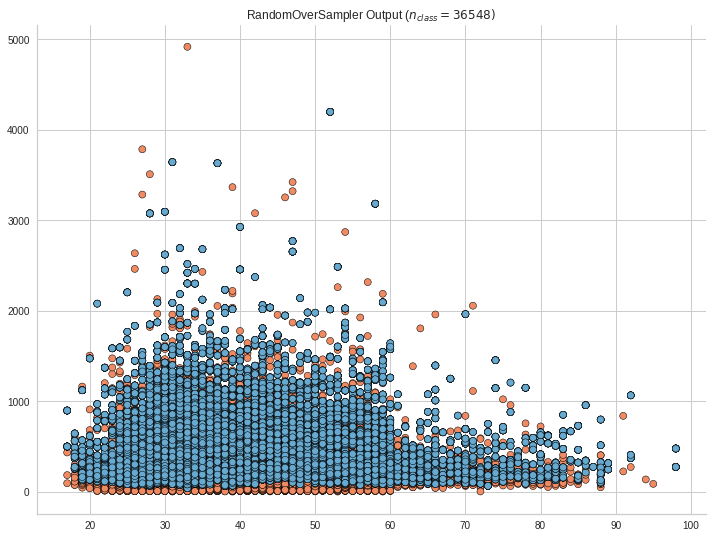

In [32]:
ros = RandomOverSampler(random_state=0)
X_over_resampled, y_over_resampled = ros.fit_resample(X, y)

colors = ['#ef8a62' if v == 0 else '#67a9cf' if v == 1 else '#f7f7f7' for v in y_over_resampled]

print(sorted(Counter(y_over_resampled).items()))

plt.figure(figsize = [12,9] )
plt.scatter(X_over_resampled[:, 0], X_over_resampled[:, 1], c=colors, linewidth=0.5, edgecolor='black')
sns.despine()
plt.title("RandomOverSampler Output ($n_{class}=36548)$")

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning:

Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.



[(0, 36548), (1, 36548)]


Text(0.5, 1.0, 'RandomOverSampler Output ($n_{class}=36548)$')

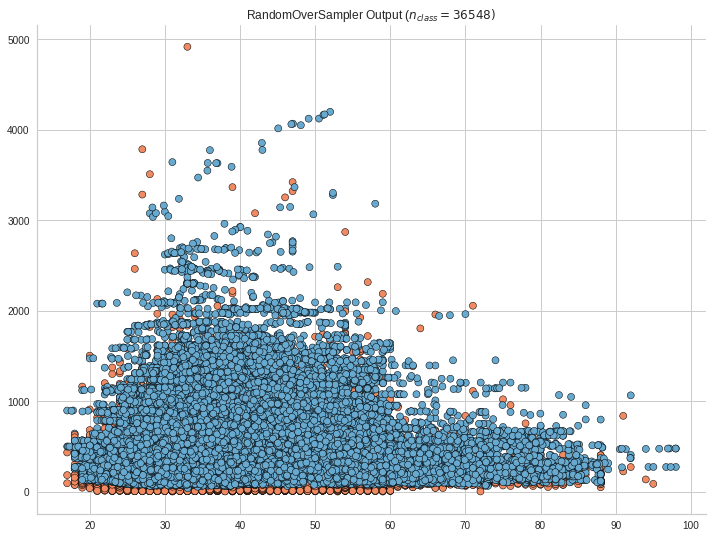

In [33]:
smote = SMOTE(ratio='minority')
X_sm_resampled, y_sm_resampled = smote.fit_resample(X, y)

colors = ['#ef8a62' if v == 0 else '#67a9cf' if v == 1 else '#f7f7f7' for v in y_sm_resampled]
print(sorted(Counter(y_sm_resampled).items()))

plt.figure(figsize = [12,9] )
plt.scatter(X_sm_resampled[:, 0], X_sm_resampled[:, 1], c=colors, linewidth=0.5, edgecolor='black')
sns.despine()
plt.title("RandomOverSampler Output ($n_{class}=36548)$")

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning:

Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.



[(0, 4640), (1, 4640)]


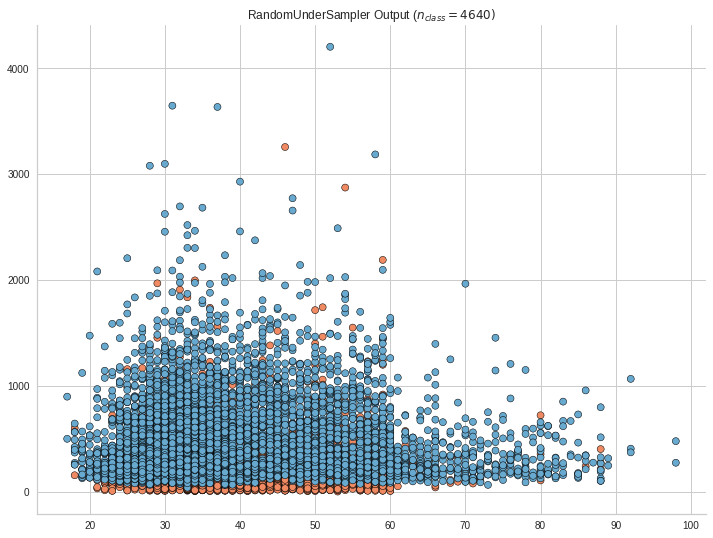

In [34]:
rus = RandomUnderSampler(random_state=0)
X_under_resampled, y_under_resampled = rus.fit_resample(X, y)
colors = ['#ef8a62' if v == 0 else '#67a9cf' if v == 1 else '#f7f7f7' for v in y_under_resampled]
print(sorted(Counter(y_under_resampled).items()))

plt.figure(figsize = [12,9])
plt.scatter(X_under_resampled[:, 0], X_under_resampled[:, 1], c=colors, linewidth=0.5, edgecolor='black')
sns.despine()
plt.title("RandomUnderSampler Output ($n_{class}=4640)$")
pass

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning:

Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.

/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning:

Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.



(array([0, 1]), array([36265, 36265]))


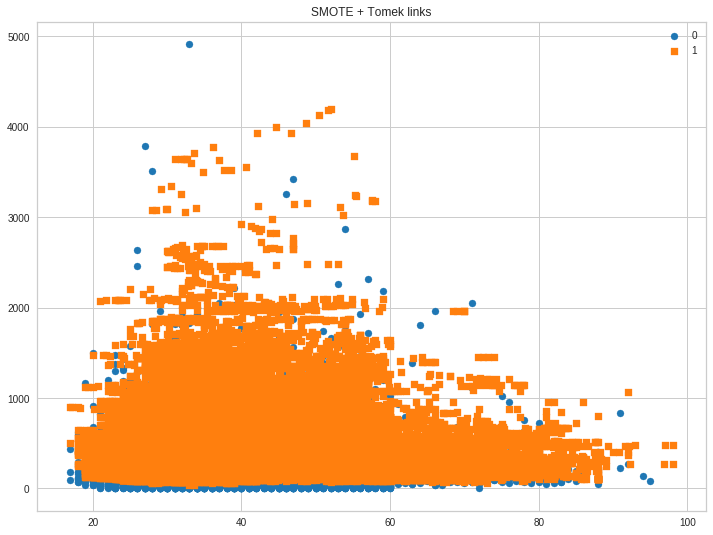

In [35]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(ratio='auto')
X_smt, y_smt = smt.fit_sample(X, y)
print(np.unique(y_smt, return_counts=True))

def plot_2d_space(X, y, label='Classes'):   
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    plt.figure(figsize = [12,9])
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(
            X[y==l, 0],
            X[y==l, 1],
            c=c, label=l, marker=m
        )
    plt.title(label)
    plt.legend(loc='upper right')
    plt.show()

plot_2d_space(X_smt, y_smt, 'SMOTE + Tomek links')

# Data Modelling & Evaluation

## Plotting Functions

### ROC plot function

In [36]:
"""
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], ls="--")
    plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
    """

'\ndef plot_roc_curve(fpr, tpr):\n    plt.plot(fpr, tpr, color=\'orange\', label=\'ROC\')\n    plt.plot([0, 1], ls="--")\n    plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")\n    plt.ylabel(\'True Positive Rate\')\n    plt.xlabel(\'False Positive Rate\')\n    plt.title(\'Receiver Operating Characteristic (ROC) Curve\')\n    plt.legend()\n    plt.show()\n    '

In [0]:
def plot_roc_curve(fpr, tpr):
  fig = go.Figure()
  fig.add_trace(go.Scatter(x=fpr, y=tpr,
                    mode='lines',
                    name='ROC Curve'))
  fig.add_trace(go.Scatter(x=[0,1], y=[0,1],
                    mode='lines+markers',
                    name='Baseline'))

  fig.update_layout(
    title="Receiver operating characteristic",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    font=dict(
        family="Courier New, monospace",
        size=18,
        color="#7f7f7f"
    )
)

  fig.show()

### Feature importance plotting function

In [0]:
def feature_imp(X, model):

  p = model.feature_importances_
  q = X.columns.values
  data = [go.Bar(
            x= q,
             y= p, 
             orientation='v',
            width = 0.5,
            marker=dict(
               color = model.feature_importances_,
            colorscale='Portland',
            showscale=True,
            reversescale = False
            ),
            opacity=0.6
        )]

  layout= go.Layout(
    autosize= True,
    title= 'Barplots of XGb-Classification Feature Importance',
    hovermode= 'closest',
    yaxis=dict(
        title= 'Feature Importance',
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
          )
  fig = go.Figure(data=data, layout=layout)
  py.iplot(fig, filename='bar-direct-labels')

### Learning Curve

In [0]:
def plot_learning_curve(train_sizes,train_scores, test_scores):

  # Create means and standard deviations of training set scores
  train_mean = np.mean(train_scores, axis=1)
  train_std = np.std(train_scores, axis=1)

  # Create means and standard deviations of test set scores
  test_mean = np.mean(test_scores, axis=1)
  test_std = np.std(test_scores, axis=1)

  fig = go.Figure()
  fig.add_trace(go.Scatter(x=train_sizes, y=train_mean,
                    mode='lines', line_color = 'rgb(111, 231, 219)',
                    name='Training score'))
  fig.add_trace(go.Scatter(x=train_sizes, y=test_mean,
                    mode='lines+markers',
                    name='Cross-validation score',fill='tonexty',line_color='indigo'))

  fig.update_layout(
    title="Learning Curve",
    xaxis_title="Training Set Size",
    yaxis_title="Auc Score",
    font=dict(
        family="Courier New, monospace",
        size=18,
        color="#7f7f7f")
        )
  fig.show()

### Backup model and metrics function

In [0]:
def model_metrics_plots(X_train, y_train,X_test,y_test, model):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print('\n*Confusion matrix:\n')
    sns.set(font_scale=1.4)
    sns.heatmap(cm, cmap='RdBu',annot = True)
    plt.show()

    from sklearn.metrics import classification_report
    print ('\n*Classification Report:\n', classification_report(y_test, y_pred))


    #ROC Curves
    probs = probs[:, 1]
    auc = roc_auc_score(y_test, probs)
    print('AUC: %.2f' % auc)
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    plot_roc_curve(y_test, probs)
  
    #Print Feature Importance:
    sns.set(font_scale=1.4)
    sns.set_style("white")
    sns.set_context("notebook")
    fig = plt.figure(figsize = [12,7])
    ax = fig.add_subplot()
    viz = FeatureImportances(model, ax=ax)
    viz.fit(X, y)
    viz.poof()

## Hypertuning models

Lets us create a training, testing and a validation data sets. then we create models based on the sampling processes

### Building models

In [0]:
X_model_us = pd.DataFrame(X_under_resampled, columns = X.columns.values)
y_model_us = y_under_resampled
X_model_os = pd.DataFrame(X_over_resampled, columns = X.columns.values)
y_model_os = y_over_resampled
X_model_sm = pd.DataFrame(X_sm_resampled, columns = X.columns.values)
y_model_sm = y_sm_resampled
X_model_smt = pd.DataFrame(X_smt, columns = X.columns.values)
y_model_smt = y_smt

X1_train, X1_test, y1_train, y1_test = train_test_split(X_model_us, y_model_us,test_size=0.1, random_state=123)
X2_train, X2_test, y2_train, y2_test = train_test_split(X_model_os, y_model_os,test_size=0.25, random_state=123)
X3_train, X3_test, y3_train, y3_test = train_test_split(X_model_sm, y_model_sm,test_size=0.25, random_state=123)
X4_train, X4_test, y4_train, y4_test = train_test_split(X_model_smt, y_model_smt,test_size=0.25, random_state=123)

In [0]:
def hyper(X_train, X_test, y_train, y_test):

  def xgbc_cv(max_depth,learning_rate,n_estimators,reg_alpha):
    from sklearn.metrics import roc_auc_score
    import numpy as np
    
    estimator_function = xgb.XGBClassifier(max_depth=int(max_depth),
                                           learning_rate= learning_rate,
                                           n_estimators= int(n_estimators),
                                           eval_metric = 'auc',
                                           reg_alpha = reg_alpha,
                                           nthread = -1,
                                           objective='binary:logistic',
                                           seed = seed)
    # Fit the estimator
    estimator_function.fit(X_train,y_train)
    
    # calculate out-of-the-box roc_score using validation set 1
    probs = estimator_function.predict_proba(X_test)
    probs = probs[:,1]
    val1_roc = roc_auc_score(y_test,probs)
    
    # return the mean validation score to be maximized 
    return np.array(val1_roc)


  # alpha is a parameter for the gaussian process
  # Note that this is itself a hyperparemter that can be optimized.
  gp_params = {"alpha": 1e-10}

  # We create the BayesianOptimization objects using the functions that utilize
  # the respective classifiers and return cross-validated scores to be optimized.

  seed = 112 # Random seed

  # We create the bayes_opt object and pass the function to be maximized
  # together with the parameters names and their bounds.
  # Note the syntax of bayes_opt package: bounds of hyperparameters are passed as two-tuples

  hyperparameter_space = {
    'max_depth': (5, 20),
    'learning_rate': (0, 1),
    'n_estimators' : (10,100),
    'reg_alpha': (0,1)
  }

  xgbcBO = BayesianOptimization(f = xgbc_cv, 
                             pbounds =  hyperparameter_space,
                             random_state = seed,
                             verbose = 10)

  # Finally we call .maximize method of the optimizer with the appropriate arguments
  # kappa is a measure of 'aggressiveness' of the bayesian optimization process
  # The algorithm will randomly choose 3 points to establish a 'prior', then will perform 
  # 10 interations to maximize the value of estimator function
  xgbcBO.maximize(init_points=5,n_iter=20,acq='ucb', kappa= 3, **gp_params)

  global param_model

  param_model= xgbcBO.max

  return param_model

### Undersample training model

In [42]:
X_model_us1 = X1_train
y_model_us1 = y1_train
#y_model_us = y_model_us.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_model_us1, y_model_us1,test_size=0.1)
print(X_model_us1.shape, y_model_us1.shape)

(8352, 53) (8352,)


In [43]:
hyper(X_train, X_test, y_train, y_test)

|   iter    |  target   | learni... | max_depth | n_esti... | reg_alpha |
-------------------------------------------------------------------------
|  1        |  0.9388   |  0.3751   |  14.6     |  95.5     |  0.07568  |
|  2        |  0.9399   |  0.7769   |  17.49    |  14.93    |  0.8177   |
|  3        |  0.9371   |  0.8854   |  15.84    |  10.23    |  0.9812   |
|  4        |  0.948    |  0.3434   |  6.421    |  45.52    |  0.004945 |
|  5        |  0.9376   |  0.7367   |  19.34    |  83.85    |  0.345    |
|  6        |  0.9415   |  0.9571   |  5.024    |  83.45    |  0.9585   |
|  7        |  0.9408   |  0.009384 |  5.336    |  36.82    |  0.9996   |
|  8        |  0.9468   |  0.03979  |  5.007    |  70.82    |  0.04511  |
|  9        |  0.9275   |  0.9791   |  19.85    |  44.37    |  0.01626  |
|  10       |  0.9447   |  0.9516   |  5.003    |  18.99    |  0.05567  |
|  11       |  0.9397   |  0.9885   |  5.097    |  60.19    |  0.01193  |
|  12       |  0.948    |  0.2516   | 

{'params': {'learning_rate': 0.34341985076716164,
  'max_depth': 6.421398322643064,
  'n_estimators': 45.517832982535175,
  'reg_alpha': 0.004944924811720708},
 'target': 0.9479932229777687}

In [0]:
param_model_us = param_model

### Oversample training model

In [45]:
X_model_os1 = X2_train
y_model_os1 = y2_train
#y_model_os = y_model_os.values.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_model_os1, y_model_os1,test_size=0.2)
print(X_model_os1.shape, y_model_os1.shape)

(54822, 53) (54822,)


In [46]:
hyper(X_train, X_test, y_train, y_test)

|   iter    |  target   | learni... | max_depth | n_esti... | reg_alpha |
-------------------------------------------------------------------------
|  1        |  0.9902   |  0.3751   |  14.6     |  95.5     |  0.07568  |
|  2        |  0.9856   |  0.7769   |  17.49    |  14.93    |  0.8177   |
|  3        |  0.9821   |  0.8854   |  15.84    |  10.23    |  0.9812   |
|  4        |  0.9654   |  0.3434   |  6.421    |  45.52    |  0.004945 |
|  5        |  0.9912   |  0.7367   |  19.34    |  83.85    |  0.345    |
|  6        |  0.9763   |  0.01579  |  19.79    |  99.98    |  0.9105   |
|  7        |  0.9747   |  0.9256   |  5.196    |  98.55    |  0.9308   |
|  8        |  0.9659   |  0.0179   |  19.66    |  10.29    |  0.006038 |
|  9        |  0.9458   |  0.05904  |  5.076    |  14.47    |  0.01772  |
|  10       |  0.9865   |  1.0      |  20.0     |  48.13    |  1.0      |
|  11       |  0.9699   |  0.9732   |  5.539    |  74.91    |  0.9444   |
|  12       |  0.9896   |  0.9985   | 

{'params': {'learning_rate': 0.7367068302672689,
  'max_depth': 19.33710304228341,
  'n_estimators': 83.85484341831197,
  'reg_alpha': 0.34498299608621885},
 'target': 0.9911703267378839}

In [0]:
param_model_os = param_model

### SMOTE sample training model

In [48]:
X_model_sm1 = X3_train
y_model_sm1 = y3_train
#y_model_sm = y_model_sm.values.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_model_sm1, y_model_sm1,test_size=0.2)
print(X_model_sm1.shape, y_model_sm1.shape)

(54822, 53) (54822,)


In [49]:
%%time
hyper(X_train, X_test, y_train, y_test)

|   iter    |  target   | learni... | max_depth | n_esti... | reg_alpha |
-------------------------------------------------------------------------
|  1        |  0.9934   |  0.3751   |  14.6     |  95.5     |  0.07568  |
|  2        |  0.9931   |  0.7769   |  17.49    |  14.93    |  0.8177   |
|  3        |  0.9929   |  0.8854   |  15.84    |  10.23    |  0.9812   |
|  4        |  0.9936   |  0.3434   |  6.421    |  45.52    |  0.004945 |
|  5        |  0.993    |  0.7367   |  19.34    |  83.85    |  0.345    |
|  6        |  0.9831   |  0.02442  |  5.177    |  84.25    |  0.9826   |
|  7        |  0.9676   |  0.03583  |  5.057    |  10.12    |  0.02267  |
|  8        |  0.9933   |  0.05462  |  19.98    |  50.54    |  0.9762   |
|  9        |  0.993    |  0.827    |  19.91    |  99.87    |  0.8128   |
|  10       |  0.9932   |  0.3875   |  19.89    |  10.06    |  0.03787  |
|  11       |  0.9919   |  0.8982   |  5.193    |  99.85    |  0.06737  |
|  12       |  0.9924   |  0.999    | 

{'params': {'learning_rate': 0.07501121826852408,
  'max_depth': 10.169111711620376,
  'n_estimators': 99.94640561875438,
  'reg_alpha': 0.9270934467837272},
 'target': 0.9941476546490766}

In [0]:
param_model_sm = param_model

### Combination of SMOTE & Tomek training model

In [51]:
X_model_smt1 = X4_train
y_model_smt1 = y4_train
#y_model_smt = y_model_smt.values.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_model_smt1, y_model_smt1,test_size=0.2)
print(X_model_smt1.shape, y_model_smt1.shape)

(54397, 53) (54397,)


In [52]:
%%time
hyper(X_train, X_test, y_train, y_test)

|   iter    |  target   | learni... | max_depth | n_esti... | reg_alpha |
-------------------------------------------------------------------------
|  1        |  0.9928   |  0.3751   |  14.6     |  95.5     |  0.07568  |
|  2        |  0.9925   |  0.7769   |  17.49    |  14.93    |  0.8177   |
|  3        |  0.9922   |  0.8854   |  15.84    |  10.23    |  0.9812   |
|  4        |  0.9929   |  0.3434   |  6.421    |  45.52    |  0.004945 |
|  5        |  0.9927   |  0.7367   |  19.34    |  83.85    |  0.345    |
|  6        |  0.9863   |  0.002596 |  19.1     |  53.05    |  0.9708   |
|  7        |  0.991    |  0.9793   |  5.055    |  84.13    |  0.005672 |
|  8        |  0.9918   |  0.7762   |  5.328    |  11.41    |  0.01083  |
|  9        |  0.9924   |  0.9388   |  19.91    |  99.36    |  0.7167   |
|  10       |  0.9922   |  0.3875   |  19.89    |  10.06    |  0.03787  |
|  11       |  0.9918   |  0.9931   |  13.52    |  35.73    |  0.004985 |
|  12       |  0.974    |  0.03201  | 

{'params': {'learning_rate': 0.1849265600857345,
  'max_depth': 19.9985424306512,
  'n_estimators': 99.91497340693041,
  'reg_alpha': 0.058014625922962915},
 'target': 0.9932368485904379}

In [0]:
param_model_smt = param_model

## Validating Model

Validation model function that displays the diagnostic measures

In [0]:
def valid_model(X_model,y_model, params_model):

  X = X_model
  y = y_model
  #y_model_us = y_model_us.reshape(-1,1)
  X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3)
  print(X_model.shape, y_model.shape)

  model = XGBClassifier(objective = 'binary:logistic',
                        eval_metric = 'auc',
                        learning_rate = params_model['params']['learning_rate'],
                        max_depth = int(round(params_model['params']['max_depth'])),
                        n_estimators = int(round(params_model['params']['n_estimators'])),
                        reg_alpha = params_model['params']['reg_alpha'])

  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  probs = model.predict_proba(X_test)

  global cm, acc, sp, prec, rec, f1, auc
  cm = confusion_matrix(y_test, y_pred)

  print('\n*Confusion matrix:\n')
  sns.set(font_scale=1.4)
  sns.heatmap(cm, cmap='RdBu',annot = True)
  plt.show()

  from sklearn.metrics import classification_report
  print ('\n*Classification Report:\n', classification_report(y_test, y_pred))

  #ROC Curves
  probs = probs[:, 1]
  acc = accuracy_score(y_test,y_pred)
  #specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  sp = tn / (tn+fp)
  auc = roc_auc_score(y_test, probs)
  prec = precision_score(y_test,y_pred)
  rec = recall_score(y_test,y_pred)
  f1 = f1_score(y_test, y_pred)
  print('AUC: %.2f' % auc)
  fpr, tpr, thresholds = roc_curve(y_test, probs)
  fig = go.Figure()
  fig.add_trace(go.Scatter(x=fpr, y=tpr,
                    mode='lines',
                    name='ROC Curve'))
  fig.add_trace(go.Scatter(x=[0,1], y=[0,1],
                    mode='lines+markers',
                    name='Baseline'))

  fig.update_layout(
    title="Receiver operating characteristic",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    font=dict(
        family="Courier New, monospace",
        size=18,
        color="#7f7f7f")
      )
  fig.show()

  # Feature importance 
  global model_feature_imp
  #feature_imp(X_model_us,model_1)
  model_feature_imp = feature_imp(X_model_us,model)

  return cm, acc, sp, prec, rec, f1, auc, model_feature_imp


### Undersample model

(8352, 53) (8352,)

*Confusion matrix:



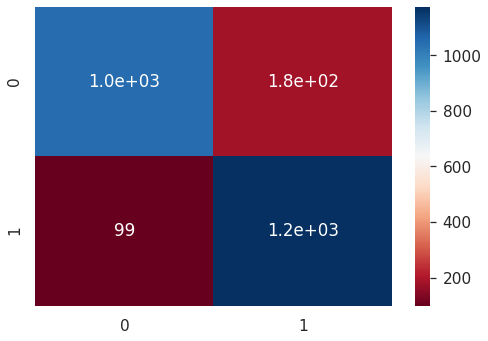


*Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88      1233
           1       0.87      0.92      0.89      1273

    accuracy                           0.89      2506
   macro avg       0.89      0.89      0.89      2506
weighted avg       0.89      0.89      0.89      2506

AUC: 0.94


(array([[1050,  183],
        [  99, 1174]]),
 0.8874700718276137,
 0.851581508515815,
 0.8651436993367723,
 0.9222309505106049,
 0.8927756653992397,
 0.9421792306236777,
 None)

In [96]:
valid_model(X1_train, y1_train, param_model_us)

In [0]:
cm1, acc1, sp1, prec1, rec1, f1,auc1, model_feature_imp1 = cm, acc, sp, prec, rec, f1,auc, model_feature_imp

### Oversample  model

(54822, 53) (54822,)

*Confusion matrix:



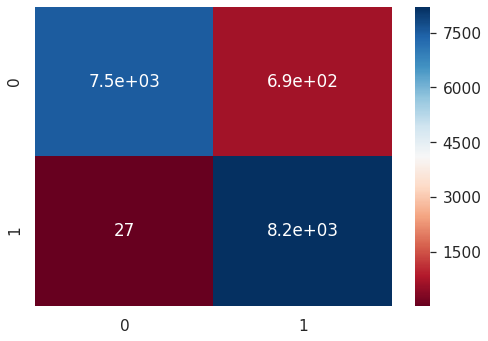


*Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.95      8215
           1       0.92      1.00      0.96      8232

    accuracy                           0.96     16447
   macro avg       0.96      0.96      0.96     16447
weighted avg       0.96      0.96      0.96     16447

AUC: 0.99


(array([[7522,  693],
        [  27, 8205]]),
 0.9562230193956345,
 0.9156421180766889,
 0.9221173297370195,
 0.9967201166180758,
 0.9579684763572679,
 0.9873589962895862,
 None)

In [98]:
valid_model(X2_train, y2_train, param_model_os)

In [0]:
cm2, acc2, sp2, prec2, rec2, f2,auc2, model_feature_imp2 = cm, acc, sp, prec, rec, f1,auc, model_feature_imp

### SMOTE sample model

(54822, 53) (54822,)

*Confusion matrix:



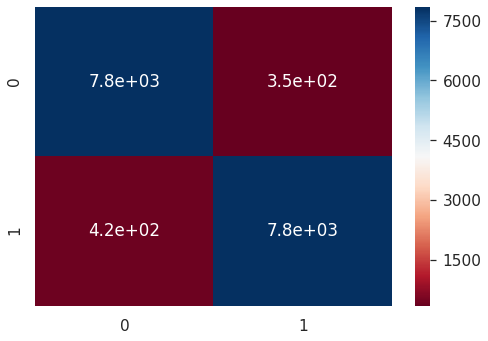


*Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      8195
           1       0.96      0.95      0.95      8252

    accuracy                           0.95     16447
   macro avg       0.95      0.95      0.95     16447
weighted avg       0.95      0.95      0.95     16447

AUC: 0.99


(array([[7844,  351],
        [ 418, 7834]]),
 0.9532437526600596,
 0.9571690054911531,
 0.9571166768478925,
 0.9493456131846825,
 0.9532153069294883,
 0.9937469186755105,
 None)

In [100]:
valid_model(X3_train, y3_train, param_model_sm)

In [0]:
cm3, acc3, sp3, prec3, rec3, f3,auc3, model_feature_imp3 = cm, acc, sp, prec, rec, f1,auc, model_feature_imp

### Combination of SMOTE & Tomek model

(54397, 53) (54397,)

*Confusion matrix:



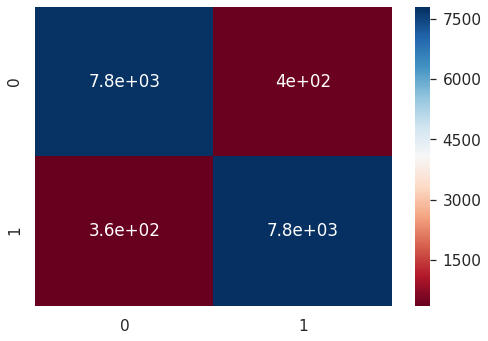


*Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      8162
           1       0.95      0.96      0.95      8158

    accuracy                           0.95     16320
   macro avg       0.95      0.95      0.95     16320
weighted avg       0.95      0.95      0.95     16320

AUC: 0.99


(array([[7767,  395],
        [ 359, 7799]]),
 0.9537990196078432,
 0.9516049987748101,
 0.9517939956065413,
 0.9559941162049522,
 0.953889432485323,
 0.9939693263389877,
 None)

In [102]:
valid_model(X4_train, y4_train, param_model_smt)

In [0]:
cm4, acc4, sp4, prec4, rec4, f4, auc4, model_feature_imp4 = cm, acc, sp, prec, rec, f1,auc, model_feature_imp

## Further Evaluation

In [0]:
#cv = StratifiedKFold(n_splits=5, random_state=0, shuffle=True)
#train_sizes = [100,500,1000,2500,5000,7500]

### Undersample model

In [0]:
%%time
train_sizes, train_scores, test_scores = learning_curve(estimator = model_1,
                                                              X = X1_train,
                                                              y = y1_train, train_sizes=np.linspace(0.01, 1.0, 50), cv = cv,
                                                              scoring = 'roc_auc')
plot_learning_curve(train_sizes,train_scores,test_scores)

CPU times: user 2min 33s, sys: 633 ms, total: 2min 33s
Wall time: 2min 34s


### Oversample model

In [0]:
%%time
train_sizes, train_scores, test_scores = learning_curve(estimator = model_2,
                                                              X = X2_train,
                                                              y = y2_train, train_sizes=np.linspace(0.01, 1.0, 50), cv = 3,
                                                              scoring = 'roc_auc')
plot_learning_curve(train_sizes,train_scores,test_scores)

CPU times: user 25min 52s, sys: 1.83 s, total: 25min 54s
Wall time: 25min 55s


### SMOTE sample model

In [0]:
%%time
train_sizes, train_scores, test_scores = learning_curve(estimator = model_3,
                                                              X = X3_train,
                                                              y = y3_train, train_sizes=np.linspace(0.01, 1.0, 50), cv = 3,
                                                              scoring = 'roc_auc')
plot_learning_curve(train_sizes,train_scores,test_scores)

CPU times: user 6min 32s, sys: 704 ms, total: 6min 33s
Wall time: 6min 33s


### SMOTE & Tomek model

In [0]:
%%time
train_sizes, train_scores, test_scores = learning_curve(estimator = model_4,
                                                              X = X4_train,
                                                              y = y4_train, train_sizes=np.linspace(0.01, 1.0, 50), cv = 3,
                                                              scoring = 'roc_auc')
plot_learning_curve(train_sizes,train_scores,test_scores)

CPU times: user 6min 30s, sys: 625 ms, total: 6min 30s
Wall time: 6min 30s


In [0]:
gc.collect()

268

## Model Results

The following subsection consists of compilation of evaluation metrics of various models belonging to different sampling methods. The model's parameters have been hypertuned and validated. 

In [0]:
results_score = pd.DataFrame({'Models':['Under-sample', 'Over-sample', 'SMOTE-sample', 'SMOTE&Tomek-sample'],
                               'Accuracy':[acc1, acc2, acc3, acc4],
                               'Specificity': [sp1, sp2, sp3, sp4],
                               'Precision':[prec1, prec2, prec3, prec4],
                               'Recall':[rec1, rec2, rec3, rec4],
                               'F-1 score': [f1,f2,f3,f4],
                               'AUC': [auc1, auc2, auc3, auc4]})

Interpretation of the metrics

1. Accuracy: Of all the actual points how many of them are correctly classified.

2. Specificity: From all actual negative points how many of them are correctly predicted to be negative.

3. Precision: From all predicted positive point how many of them are actually positive.

4. Recall: From all actual positive points how many of them are correctly predicted to be positive.

5. F1-Score: It is the harmonic mean of precision and recall.It is used where we need both precision and recall.

6. AUC: If we have two different class and we don’t know which is positive and which one is negative, AND if we pass such points through model of AUC (0.75) then there is chance that our model will correctly classify 75% of points.

NOTE: AUC of random model is (0.5). If we find model with AUC (0.2) then swap the class labels.
AUC does not care about the actual values i.e it does not depend on predicted scores, it depends on ordering of data.

In [105]:
results_score

,Models,Accuracy,Specificity,Precision,Recall,F-1 score,AUC
0,Under-sample,0.887470,0.851582,0.865144,0.922231,0.953889,0.942179
1,Over-sample,0.956223,0.915642,0.922117,0.996720,0.957968,0.987359
2,SMOTE-sample,0.953244,0.957169,0.957117,0.949346,0.953215,0.993747
3,SMOTE&Tomek-sample,0.953799,0.951605,0.951794,0.955994,0.953889,0.993969


# Model Testing

### Undersample test model

In [0]:
model_1 = XGBClassifier(objective = 'binary:logistic',
                        eval_metric = 'auc',
                        learning_rate = param_model_us['params']['learning_rate'],
                        max_depth = int(round(param_model_us['params']['max_depth'])),
                        n_estimators = int(round(param_model_us['params']['n_estimators'])),
                        reg_alpha = param_model_us['params']['reg_alpha'])

model_1.fit(X1_train, y1_train)
y_pred1 = model_1.predict(X1_test)
probs1 = model_1.predict_proba(X1_test)

### Oversample test model

In [0]:
model_2 = XGBClassifier(objective = 'binary:logistic',
                        eval_metric = 'auc',
                        learning_rate = param_model_os['params']['learning_rate'],
                        max_depth = int(round(param_model_os['params']['max_depth'])),
                        n_estimators = int(round(param_model_os['params']['n_estimators'])),
                        reg_alpha = param_model_os['params']['reg_alpha'])

model_2.fit(X2_train, y2_train)
y_pred2 = model_2.predict(X2_test)
probs2 = model_2.predict_proba(X2_test)

### SMOTE test model

In [0]:
model_3 = XGBClassifier(objective = 'binary:logistic',
                        eval_metric = 'auc',
                        learning_rate = param_model_sm['params']['learning_rate'],
                        max_depth = int(round(param_model_sm['params']['max_depth'])),
                        n_estimators = int(round(param_model_sm['params']['n_estimators'])),
                        reg_alpha = param_model_sm['params']['reg_alpha'])


model_3.fit(X3_train, y3_train)
y_pred3 = model_3.predict(X3_test)
probs3 = model_3.predict_proba(X3_test)

### SMOTE & Tomek test model

In [0]:
model_4 = XGBClassifier(objective = 'binary:logistic',
                        eval_metric = 'auc',
                        learning_rate = param_model_smt['params']['learning_rate'],
                        max_depth = int(round(param_model_smt['params']['max_depth'])),
                        n_estimators = int(round(param_model_smt['params']['n_estimators'])),
                        reg_alpha = param_model_smt['params']['reg_alpha'])


model_4.fit(X4_train, y4_train)
y_pred4 = model_4.predict(X4_test)
probs4 = model_4.predict_proba(X4_test)

# Feedback

1. How well did the model perform?
2. Iterative process for model refinement and redeployment?

## Cost benefit analysis

Let us consider a hypothetical situation where the data is directed towards a marketing campaign. The built-in model is used to contact a client to subscribe a term deposit or not. Cost analysis is carried out to test the expenses incurred to money benefitted by deployment of machine learning model.

1. Average cost of marketing/Administation = $5

2. Assuming for every successfull deposit cost, benefit obtained = $100

In our case we are considering average costs and benefits. this is purely done for the sake of simplicity. we are not genrating any additional data as it may change the dynamic of the data behaviour.

NOTE: In a real case scenario the following costs and interest rate tend to change due to varying factors.

Interpretation of term deposit in the case of banks.
How a Bank uses a Term Deposit

If a customer places money in a term deposit, the bank can invest the money in other financial products that pay a higher rate of return (RoR) than what the bank is paying the customer for the use of their funds. The bank can also lend the money out to its other clients thereby receiving a higher interest rate from the borrowers as compared to what the bank is paying in interest for the term deposit.

For example, a lender may offer a 2% rate for term deposits with a two-year maturity. The funds deposited are then structured as loans to borrowers who are charged 7% in interest on those notes. This difference in rates means that the bank makes a net 5% return. The spread between the rate the bank pays its customers for deposits and the rate it charges its borrowers is called net interest margin. Net interest margin is a profitability metric for banks.

Banks are businesses, as such, they want to pay the lowest rate possible for term deposits and charge a much higher rate to borrowers for loans. This practice increases their margins or profitability. However, there is a balance the bank needs to maintain. If it pays too little interest, it won't attract new investors into the term deposit accounts. Also, if they charge too high of a rate on loans, it won't attract new borrowers.

Lets us understand how the cost are distributed based on the confusion matrix (Cost benefit matrix):

1. True Positives, T.P ($0 cost, $0 benefit) = $0

2. True Negatives, T.N ($5 cost, $100 benefit) = 100 - 5 = $95

3. False Positve, F.P ($0 cost, $0 benefit) = -$95

4. False Negatives, F.N ($5 cost, $0 benefit) = 0 - 5 = $ -5


Expected Profit: Matrix multiplication of confusion matrix and cost benefit matrix

In [80]:
# Cost benefit matrix
labels = ["Not Subscribed","Subscribed"]
cbm = pd.DataFrame({"Not Subscribed": [0,-5],"Subscribed": [-95,95]},index=labels)
cbm

,Not Subscribed,Subscribed
Not Subscribed,0,-95
Subscribed,-5,95


In [81]:
cbm.values

array([[  0, -95],
       [ -5,  95]])

In [0]:
actual_us_benefit = sum(y1_test*95)
actual_os_benefit = sum(y2_test*95)
actual_sm_benefit = sum(y3_test*95)
actual_smt_benefit = sum(y4_test*95)

In [119]:
"""
#Expected Profit 

#Summed values after element wise multiplication
overall_expected_profit1 = sum(sum((cbm.values*cm1)))
overall_expected_profit2 = sum(sum((cbm.values*cm2)))
overall_expected_profit3 = sum(sum((cbm.values*cm3)))
overall_expected_profit4 = sum(sum((cbm.values*cm4)))

#Cost benefit analysis for various models
print("\n The value of expected profit for under-sample model = ${}".format(overall_expected_profit1))
print("\n The value of expected profit for over-sample model = ${}".format(overall_expected_profit2))
print("\n The value of expected profit for smote-sample model= ${}".format(overall_expected_profit3))
print("\n The value of expected profit for smote&tomek model= ${}".format(overall_expected_profit4))
"""

'\n#Expected Profit \n\n#Summed values after element wise multiplication\noverall_expected_profit1 = sum(sum((cbm.values*cm1)))\noverall_expected_profit2 = sum(sum((cbm.values*cm2)))\noverall_expected_profit3 = sum(sum((cbm.values*cm3)))\noverall_expected_profit4 = sum(sum((cbm.values*cm4)))\n\n#Cost benefit analysis for various models\nprint("\n The value of expected profit for under-sample model = ${}".format(overall_expected_profit1))\nprint("\n The value of expected profit for over-sample model = ${}".format(overall_expected_profit2))\nprint("\n The value of expected profit for smote-sample model= ${}".format(overall_expected_profit3))\nprint("\n The value of expected profit for smote&tomek model= ${}".format(overall_expected_profit4))\n'

In [114]:
import gc
gc.collect()

69164

In [0]:
# Predicted benefit
pred_us_benefit = sum(y_pred1*95)
pred_os_benefit = sum(y_pred2*95)
pred_sm_benefit = sum(y_pred3*95)
pred_smt_benefit = sum(y_pred4*95)

In [0]:
#Calculating the true loss
tr1 = actual_us_benefit - pred_us_benefit
tr2 = actual_os_benefit - pred_os_benefit
tr3 = actual_sm_benefit - pred_sm_benefit
tr4 = actual_smt_benefit - pred_smt_benefit 

In [0]:
#Percentage of true loss
pr1 = (tr1/actual_us_benefit)*100
pr2 = (tr2/actual_os_benefit)*100
pr3 = (tr3/actual_sm_benefit)*100
pr4 = (tr4/actual_smt_benefit)*100

In [0]:
Profits = pd.DataFrame({'Models':['Under-sample', 'Over-sample', 'SMOTE-sample', 'SMOTE&Tomek-sample'],
                        #'Expected_profit':[overall_expected_profit1,overall_expected_profit2,overall_expected_profit3,overall_expected_profit4],
                        'True_loss':[tr1, tr2, tr3, tr4],
                        '% of loss':[pr1, pr2, pr3, pr4]
                        })

In [130]:
Profits['True_loss'] = abs(Profits['True_loss'])
Profits['% of loss'] = abs(Profits['% of loss'])
Profits

,Models,True_loss,% of loss
0,Under-sample,2945,6.609808
1,Over-sample,65265,7.531243
2,SMOTE-sample,2185,0.252138
3,SMOTE&Tomek-sample,7315,0.848672


# Conclusion

Therefore, as described above in the profits data frame. the SMOTE-sample model is to be used for deployment.